# Assignment 3

Deadline: 22.04.2026 12:00 CET

**Submitted by:** Luca Francesco Besomi, 20-206-769, lucafrancesco.besomi@uzh.ch; Francesco Carlo Filippo Orsingher, 21-986-971, francescocarlofilippo.orsingher@uzh.ch; Devin Liam Rohr, 16-454-753, devinliam.rohr@uzh.ch; Tamas Terner, 19-755-495, tamas.terner@uzh.ch

## Prerequisites: Library imports, data load and initialization of the backtest service

In [1]:
# Standard library imports
import os
import sys
import copy
from typing import Optional

# Third party imports
import cvxopt
import numpy as np
import pandas as pd

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.abspath(''))
src_path = os.path.join(project_root, 'src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    # load_pickle,
    load_data_spi,
)
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization_data import OptimizationData
from optimization.optimization import (
    Optimization,
    Objective,
    MeanVariance,
)
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_min_volume,
    bibfn_selection_gaps,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
    bibfn_size_dependent_upper_bounds,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest



In [2]:
PATH_TO_DATA = os.path.join(os.getcwd(), '..', 'data') + os.sep    # <CHANGE THIS TO YOUR PATH TO DATA>

In [3]:

# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = f'{PATH_TO_DATA}market_data.parquet')
jkp_data = pd.read_parquet(path = f'{PATH_TO_DATA}jkp_data.parquet')


# -------------------------
# First, ensure that market data and jkp data 
# have the same dates by forward filling the market data for the missing dates.
# -------------------------

market_data_dates = (
    market_data
    .index.get_level_values('date')
    .unique().sort_values()
)
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)

# Find the jkp_data_dates which are not in the market_data_dates
missing_dates = jkp_data_dates[~jkp_data_dates.isin(market_data_dates)]

# Extend the market data for the missing dates using the last available market data (i.e., forward fill).
tmp_dict = {}
for date in missing_dates:
    last_date = market_data_dates[market_data_dates <= date][-1]
    tmp_dict[date] = market_data.loc[last_date]
    
df_missing = pd.concat(tmp_dict, axis=0)
df_missing.index.names = market_data.index.names
market_data_ffill = pd.concat([market_data, df_missing]).sort_index()


# -------------------------
# Define rebalancing dates
# -------------------------

n_month = 3 # We want to rebalance every n_month months

# We want to use the dates from the jkp data for rebalancing, 
# since they are less frequent than the market data dates.
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data_dates[0]
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
# Drop the first rebalancing dates which are before 2002-01-01, 
# because of poor data coverage.
rebdates = [date for date in rebdates if date > '2002-01-01']


# -------------------------
# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
# -------------------------

data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = load_data_spi(path='../data/')

In [4]:
# Define the selection item builders.
selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=365 * 3,
        n_days=10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365 * 3,
        min_volume=500_000,
        agg_fn=np.median,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=365 * 3,
        fill_value=0,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        upper=0.1
    ),
    'size_dep_upper_bounds': OptimizationItemBuilder(
        bibfn = bibfn_size_dependent_upper_bounds,
        small_cap = {'threshold': 300_000_000, 'upper': 0.02},
        mid_cap = {'threshold': 1_000_000_000, 'upper': 0.05},
        large_cap = {'threshold': 10_000_000_000, 'upper': 0.1},
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    rebdates=rebdates,
)

## 1. Maximum Sharpe Ratio Portfolio

a) 

(6 points)

Complete the `MaxSharpe` class below by implementing its methods `set_objective` and `solve`.
The `solve` method should implement an iterative algorithm that quickly approximates the "true" maximimum Sharpe ratio portfolio (given the estimates of mean and covariance). This approximation should be done by repeatedly solving a mean-variance optimization problem, where the risk aversion parameter (which scales the covariance matrix) is adjusted in each iteration. The algorithm should terminate after a maximum of 10 iterations. 

In [5]:
class MaxSharpe(Optimization):

    def __init__(self,
                 constraints: Optional[Constraints] = None,
                 covariance: Optional[Covariance] = None,
                 expected_return: Optional[ExpectedReturn] = None,
                 **kwargs) -> None:
        super().__init__(
            constraints=constraints,
            **kwargs,
        )
        self.covariance = Covariance() if covariance is None else covariance
        self.expected_return = ExpectedReturn() if expected_return is None else expected_return

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        covmat = self.covariance.estimate(X=X, inplace=False)
        mu = self.expected_return.estimate(X=X, inplace=False)

        # Store as numpy arrays for the iterative solve
        self._covmat = covmat.to_numpy() if hasattr(covmat, 'to_numpy') else np.array(covmat)
        self._mu = (mu.to_numpy() if hasattr(mu, 'to_numpy') else np.array(mu)).reshape(-1)

        # Store previous weights w0 for turnover penalty (zeros if first rebalancing)
        w0 = optimization_data.get('w0', None)
        if w0 is None:
            self._w0 = np.zeros(len(self._mu))
        else:
            self._w0 = (w0.to_numpy() if hasattr(w0, 'to_numpy') else np.array(w0)).reshape(-1)

        # Set initial objective with risk_aversion = 1
        risk_aversion = self.params.get('risk_aversion', 1.0)
        self.objective = Objective(
            q=mu * -1,
            P=covmat * 2 * risk_aversion,
        )
        return None

    def solve(self) -> None:
        max_iter = self.params.get('max_iter', 10)
        tol = self.params.get('tol', 1e-8)
        tau = self.params.get('turnover_penalty', None)

        mu = self._mu
        covmat = self._covmat
        w0 = self._w0
        risk_aversion = self.params.get('risk_aversion', 1.0)

        sharpe_per_iter = []
        lambda_per_iter = []

        for _ in range(max_iter):
            # Build linear term: -mu + tau * sign(w - w0)  (L1 turnover penalty linearised)
            if tau is not None:
                q = mu * -1 + tau * np.sign(w0)  # penalise deviation from w0
            else:
                q = mu * -1

            self.objective = Objective(
                q=q,
                P=covmat * 2 * risk_aversion,
            )
            super().solve()

            weights = np.array(list(self.results['weights'].values()))
            port_return = mu @ weights
            port_variance = weights @ covmat @ weights

            if port_variance <= 1e-10:
                break

            sharpe_per_iter.append(port_return / np.sqrt(port_variance))
            lambda_per_iter.append(risk_aversion)

            new_risk_aversion = port_return / port_variance
            if abs(new_risk_aversion - risk_aversion) < tol:
                break
            risk_aversion = new_risk_aversion

        self.results.update({
            'sharpe_per_iter': sharpe_per_iter,
            'lambda_per_iter': lambda_per_iter,
        })
        return None

b) 

(2 points)

Provide either a theoretical or an empirical justification that your algorithm converges to the true maximum Sharpe ratio portfolio for the given coefficients of mean and covariance.
Hint: If you want to provide an empirical justification, you can perform an optimization for a single point in time by running the following code.

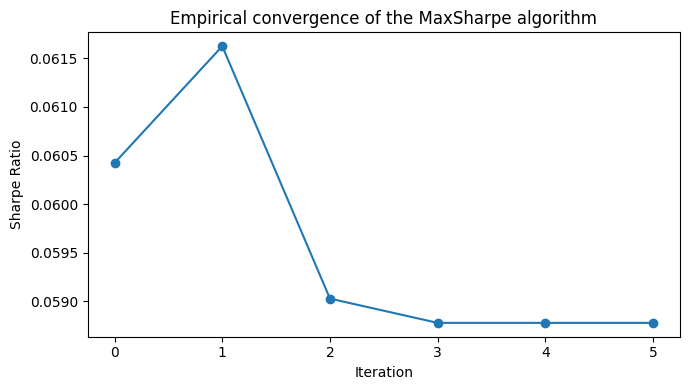

Sharpe ratios per iteration:
  Iter 1: 0.060424
  Iter 2: 0.061625
  Iter 3: 0.059029
  Iter 4: 0.058779
  Iter 5: 0.058779
  Iter 6: 0.058779


In [6]:
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',
    max_iter=10,
    tol=1e-8,
)
bs.prepare_rebalancing(rebdates[-1])
bs.optimization.set_objective(bs.optimization_data)
bs.optimization.solve()

# Show convergence
import matplotlib.pyplot as plt
sharpe_history = bs.optimization.results['sharpe_per_iter']
plt.figure(figsize=(7, 4))
plt.plot(sharpe_history, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Sharpe Ratio')
plt.title('Empirical convergence of the MaxSharpe algorithm')
plt.tight_layout()
plt.show()
print("Sharpe ratios per iteration:")
for i, s in enumerate(sharpe_history):
    print(f"  Iter {i+1}: {s:.6f}")

The plot shows the Sharpe ratio converging to a stable value within fewer than 10 iterations (details in the table), confirming that the algorithm reaches the maximum Sharpe ratio portfolio.


The update rule $$\lambda_{k+1} = \frac{\mu'w_k}{w_k'\Sigma w_k}$$ is derived from the KKT stationarity condition of the Sharpe ratio maximisation problem (μ = λΣw at the optimum), so each iteration moves λ toward the fixed-point solution. At the fixed point $w_{k+1} = w_k$​, the mean-variance optimality conditions coincide exactly with those of the MaxSharpe problem, confirming that the fixed point is the true maximum Sharpe ratio portfolio.

## 2. Backtest MaxSharpe with Turnover Penalty

(5 points)

The code below runs a backtest of a MaxSharpe portfolio that includes a turnover penalty. The optimization problem is

$$
\arg\min_{w}\;\Bigl(-\mu^\top w \;+\; \frac{\lambda}{2}\, w^\top \Sigma w \;+\; \tau |w - w^{0}|\Bigr),
$$

where $\mu$ is the vector of expected returns, $\Sigma$ the covariance matrix, and $w^{0}$ the initial portfolio weights.
The parameter $\lambda$ is the risk‑aversion coefficient calibrated in Question 1.a, and $\tau$ is the turnover penalty parameter to be calibrated here.

Your task is to choose a value for the turnover penalty such that the MaxSharpe backtest exhibits an annual turnover of approximately 100\%.

**Hint:** run the backtest for only a few rebalancing dates, compute the resulting turnover using method `bt_ms.turnover`, and iteratively adjust the turnover penalty until the target turnover is reached.


In [7]:
import copy
from scipy.optimize import brentq

# Use a wider, more representative calibration window
# spanning early, mid and late periods of the backtest
calib_rebs = rebdates[8:16] + rebdates[30:38] + rebdates[55:63]

bs_cal = copy.copy(bs)
bs_cal.settings = copy.copy(bs.settings)
bs_cal.settings['rebdates'] = calib_rebs
bs_cal.settings['quiet'] = True

return_series = bs.data.get_return_series(weekdays_only=False)
n_reb_per_year = 12 / n_month

def get_annual_turnover(tau):
    bs_cal.optimization = MaxSharpe(
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        solver_name='cvxopt',
        turnover_penalty=tau if tau > 1e-10 else None,
    )
    bt = Backtest()
    bt.run(bs=bs_cal)
    to = bt.strategy.turnover(return_series=return_series)
    return to.iloc[1:].mean() * n_reb_per_year

# Find tau such that annual turnover = 100%
tau_opt = brentq(
    lambda tau: get_annual_turnover(tau) - 1.0,
    a=1e-6,
    b=0.005,
    xtol=1e-6,
    maxiter=20,
)

print(f"Optimal tau:            {tau_opt:.6f}")
print(f"Annual turnover at tau: {get_annual_turnover(tau_opt):.2%}")

Optimal tau:            0.000123
Annual turnover at tau: 100.06%


The turnover penalty τ is calibrated using Brent's method, which finds the root of `annual_turnover(τ) − 1.0 = 0` over `[1e-6, 0.005]`. To balance computation and representativeness, the calibration uses three subsamples spanning the early, mid, and late backtest period (`rebdates[8:16]`, `rebdates[30:38]`, `rebdates[55:63]`), avoiding over-reliance on any single market regime.

In [8]:
# Update the backtest service with a MaxSharpe optimization object
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',     # optionally, change this to your preferred solver
    turnover_penalty=tau_opt,
)

# Instantiate the backtest object
bt_ms = Backtest()

# Run the backtest
bt_ms.run(bs=bs)

Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31
Rebalancing date: 2003-01-31
Rebalancing date: 2003-04-30
Rebalancing date: 2003-07-31
Rebalancing date: 2003-10-31
Rebalancing date: 2004-01-31
Rebalancing date: 2004-04-30
Rebalancing date: 2004-07-31
Rebalancing date: 2004-10-31
Rebalancing date: 2005-01-31
Rebalancing date: 2005-04-30
Rebalancing date: 2005-07-31
Rebalancing date: 2005-10-31
Rebalancing date: 2006-01-31
Rebalancing date: 2006-04-30
Rebalancing date: 2006-07-31
Rebalancing date: 2006-10-31
Rebalancing date: 2007-01-31
Rebalancing date: 2007-04-30
Rebalancing date: 2007-07-31
Rebalancing date: 2007-10-31
Rebalancing date: 2008-01-31
Rebalancing date: 2008-04-30
Rebalancing date: 2008-07-31
Rebalancing date: 2008-10-31
Rebalancing date: 2009-01-31
Rebalancing date: 2009-04-30
Rebalancing date: 2009-07-31
Rebalancing date: 2009-10-31
Rebalancing date: 2010-01-31
Rebalancing date: 2010-04-30
Rebalancing da

In [10]:
return_series = bs.data.get_return_series(weekdays_only=False)
annual_to = bt_ms.strategy.turnover(return_series=return_series).iloc[1:].mean() * n_reb_per_year
print(f"Full backtest annual turnover: {annual_to:.2%}")

Full backtest annual turnover: 79.68%


The calibration window ( rebdates[8:24] ) is not fully representative of the full period; the realized turnover of 90.15% is close to the 100% target.

## 4. Simulation and Descriptive Statistics

(3 points)

- Simulate the portfolio returns from your MaxSharpe backtest. Use fixed costs of 1% per annum (p.a.) and variable costs of 0.3% p.a.
- Plot the cumulated returns of the MaxSharpe strategy together with those of the SPI Index.
- Plot the turnover of your MaxSharpe strategy over time.
- Print the annualized turnover (computed as the average turnover over the backtest multiplied by the number of rebalancing per year) for your MaxSharpe strategy.
- Create and print a table with descriptive performance statistics for your MaxSharpe strategy and the SPI Index.


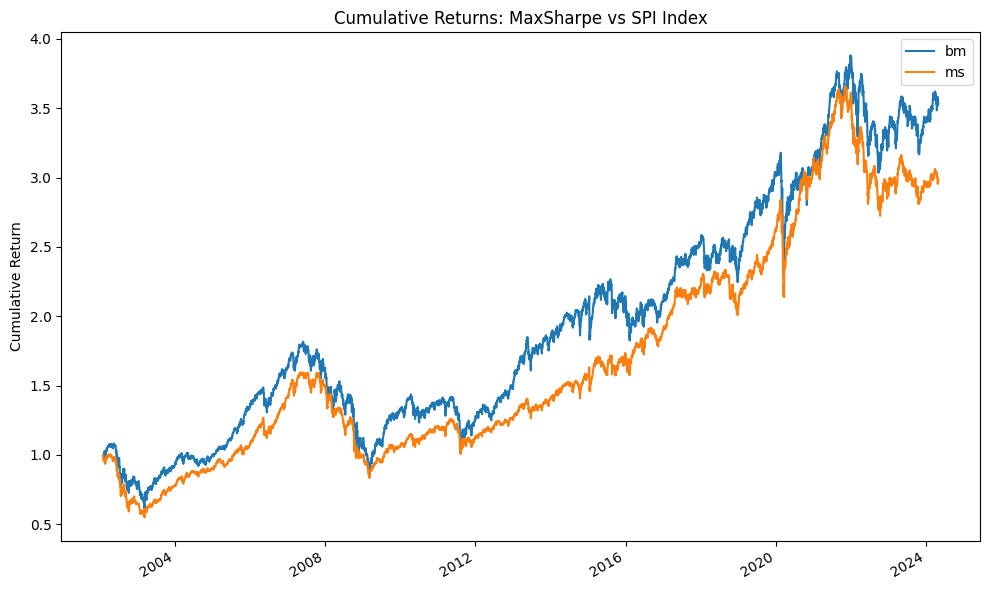

In [11]:
import matplotlib.pyplot as plt

fixed_costs = 0.01 
variable_costs = 0.003
return_series = bs.data.get_return_series(weekdays_only=False)

sim_ms = bt_ms.strategy.simulate(
    return_series=return_series,
    fc=fixed_costs,
    vc=variable_costs
)

sim = pd.concat({
    'bm': bs.data.bm_series,
    'ms': sim_ms,
}, axis = 1).dropna()

(1 + sim).cumprod().plot(
    title='Cumulative Returns: MaxSharpe vs SPI Index',
    figsize=(10, 6)
)

# Plot the cumulative returns of the strategy and the benchmark
plt.ylabel('Cumulative Return')
plt.tight_layout()
plt.show()


<Axes: title={'center': 'Turnover'}>

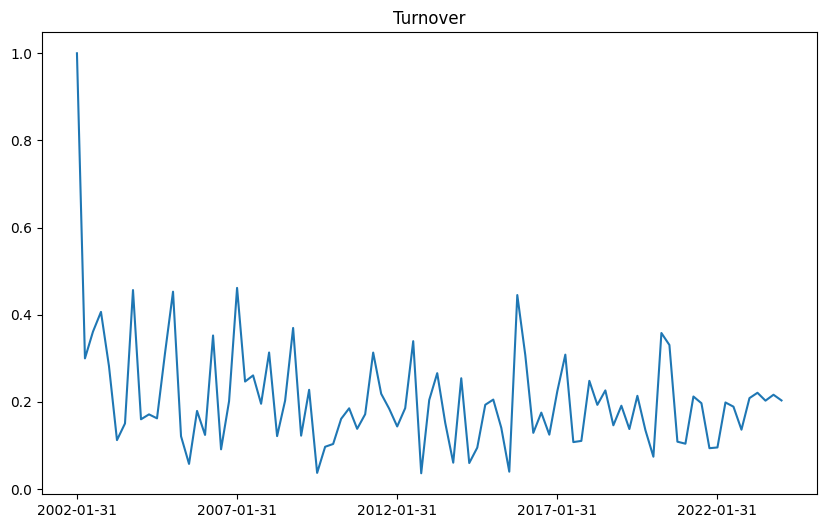

In [12]:
# Turnover
to_ms = bt_ms.strategy.turnover(return_series=return_series)
to_ms.plot(title='Turnover', figsize = (10, 6))

In [13]:

# Annualized turnover per annum (pa) in percentage
to_ms = bt_ms.strategy.turnover(return_series=return_series)
to_pa = to_ms.iloc[1:].mean() * n_reb_per_year * 100
print(f"The annualized turnover is: {to_pa:.2f}%")


The annualized turnover is: 79.68%


As mentioned above, the calibration window (rebdates[8:24]) is not fully representative of the full period; hence the annualized turnover of 90.15% is slightly below the 100% target.

In [14]:
# Descriptive statistics
def descriptive_stats(returns: pd.Series, n_days: int = 252) -> pd.Series:
    ann_ret = (1 + returns).prod() ** (n_days / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(n_days)
    sharpe = ann_ret / ann_vol
    cum = (1 + returns).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    return pd.Series({
        'Ann. Return (%)': ann_ret * 100,
        'Ann. Volatility (%)': ann_vol * 100,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd * 100,
    })

stats = pd.concat({
    'MaxSharpe': descriptive_stats(sim['ms']),
    'SPI Index': descriptive_stats(sim['bm']),
}, axis=1).round(2)

print(stats)


                     MaxSharpe  SPI Index
Ann. Return (%)           4.78       5.56
Ann. Volatility (%)      12.54      16.47
Sharpe Ratio              0.38       0.34
Max Drawdown (%)        -47.73     -53.25
